In [1]:
%load_ext autoreload
%autoreload 2

# Prova con 400 epoche e training set con 5000 x 3 dati: ottimo risultato sulla funzione semplice

Todo: provare con funzione coi seni, magari espandendo la targetnetwork

In [ ]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary libraries
import jax.numpy as jnp
import jax.random as random
import optax
from data import DataLoader
from models import MLP
from training import assign_parameters, EarlyStopping
from utils import variables_generator
from losses import compute_rrmse_alt1, compute_rrmse
from flax import nnx
import optax
import matplotlib.pyplot as plt
from training import train_and_evaluate

In [78]:
f_to_learn = lambda mu, l, k, x: jnp.exp(l*x) + 0*mu*x + k*x**2

# DATASET GENERATION
key = random.key(0)
mu_domain = (-2, 2)
l_domain = (0, 1)
k_domain = (-2, 2)
x_domain = (-1, 1)
N = 10000
n_realizations = 10
mu, l, k, x = variables_generator(N=N, n_realizations=n_realizations, var_names=['x'], var_domains=[x_domain], hypervar_domains=[mu_domain, l_domain, k_domain], hypervar_names=['mu', 'l', 'k'], key=key).values()
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADERS CREATION
split_idx = int(N * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_dataloader = DataLoader(X_train, y_train, batch_size=1024, shuffle=True)
test_dataloader = DataLoader(X_test, y_test, batch_size=1024, shuffle=False)

In [82]:
targetnetwork = MLP(input_dim=1, output_dim=1, hidden_dims=[8, 8], num_hidden_layers=2, rngs=nnx.Rngs(0), activation_functions=[nnx.tanh, nnx.tanh])
num_params = targetnetwork.num_parameters
hypernetwork = MLP(input_dim=3, output_dim=num_params, hidden_dims=[32, 32, 128], num_hidden_layers=3, rngs=nnx.Rngs(0), activation_functions=[nnx.relu, nnx.relu, nnx.relu])
epochs = 200 # AUMENTARE E GIOCARE CON SCHEDULER (SECONDO ME QUELLI COI DECAY DECADONO TROPPO, MEGLIO QUELLI A PLATEAU)

lr_schedule = optax.schedules.cosine_decay_schedule(init_value=1e-2, decay_steps=epochs*5, alpha=1e-6) #MOLTO IMPORTANTE DECAYSTEPS
# TODO: understand how to use optax.contrib.reduce_on_plateau(), in particular what "accumulation_size" input means
optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=lr_schedule))

criterion = optax.l2_loss
metrics = (compute_rrmse_alt1, compute_rrmse) # TODO: need to fix the case where the tuple only contains one metric, for now just ignore compute_rrmse
history = train_and_evaluate(
        hypernetwork=hypernetwork,
        targetnetwork=targetnetwork,
        train_loader=train_dataloader,
        val_loader=test_dataloader,
        optimizer=optimizer,
        num_epochs=epochs,
        criterion=criterion,
        metrics=metrics
)

Epoch 200/200 - Train: loss: 0.0002, compute_rrmse_alt1: 0.0146, compute_rrmse: 0.8837 - Val: loss: 0.0003, compute_rrmse_alt1: 0.0192, compute_rrmse: 0.7859: 100%|██████████| 200/200 [01:40<00:00,  2.00it/s]


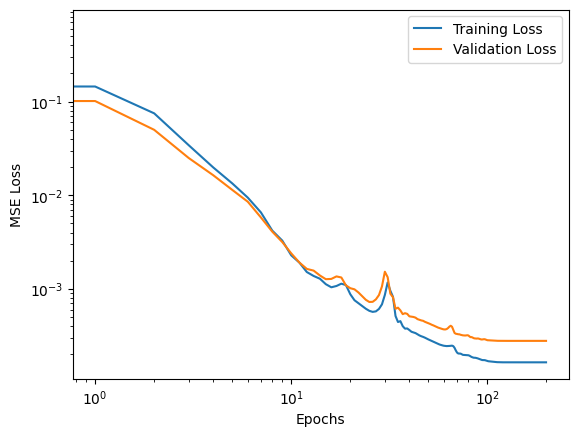

In [83]:
training_loss_history = [m['loss'] for m in history['train_metrics']]
test_loss_history = [m['loss'] for m in history['val_metrics']]
plt.loglog(range(epochs), training_loss_history, label='Training Loss')
plt.loglog(range(epochs), test_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [84]:
# PLOTTING RESULTS ON SOME EXAMPLES
N_example = 4
key_example = random.key(1)  # DON'T PUT 0 TO AVOID DATA LEAKAGE
mu_example, l_example, k_example = variables_generator(N = N_example, var_domains = [mu_domain, l_domain, k_domain], key = key_example).values()

example_hypervars = jnp.stack([mu_example, l_example, k_example], axis=1)
particular_hypervars= jnp.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
example_hypervars = jnp.vstack([example_hypervars, particular_hypervars]) 

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

In [85]:
plots_data = []

for hypervars in example_hypervars:
    w = hypernetwork(hypervars)  # get the weights from the hypernetwork
    targetnetwork = assign_parameters(targetnetwork, w)  # assign the weights to the target network
    mu, l, k = hypervars 
    y_pred = targetnetwork(x_vector)  # predicted function values
    y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])  # true function values
    
    plots_data.append({ #store data for plotting
        'x': x_vector,
        'y_pred': y_pred,
        'y_true': y_vector,
        'params': (mu, l, k)
    })

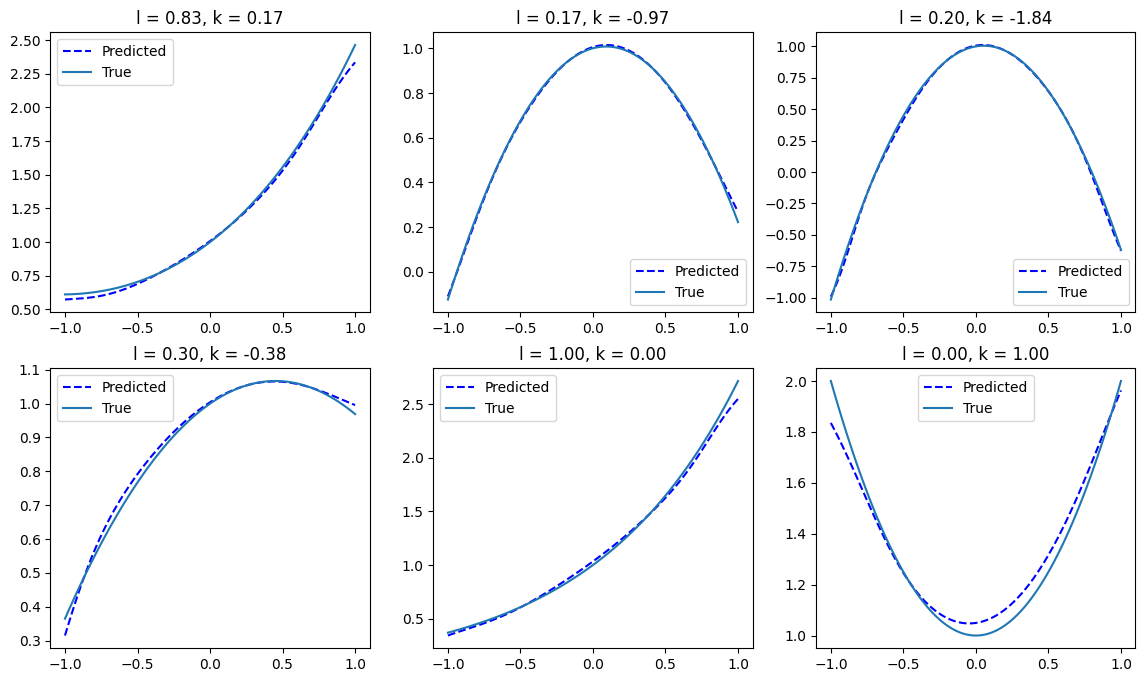

In [86]:
num_cols = 3
fig, ax = plt.subplots(2,num_cols, figsize=(14, 8))
for i, data in enumerate(plots_data[0:6]):
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_pred'], '--b')
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_true'])
    ax[i//num_cols, i%num_cols].legend(['Predicted', 'True'])
    ax[i//num_cols, i%num_cols].set_title(f'l = {data["params"][1]:.2f}, k = {data["params"][2]:.2f}')
plt.show()

In [ ]:
# CODICE UTILE SU LEARNING RATE SCHEDULER E EARLY STOPPING (NON RUNNARE)
#lr_schedule = optax.linear_schedule(init_value=1e-2, end_value=1e-6, transition_steps=epochs)
lr_schedule = optax.schedules.cosine_decay_schedule(init_value=1e-2, decay_steps=epochs, alpha=1e-6)
# TODO: understand how to use optax.contrib.reduce_on_plateau(), in particular what "accumulation_size" input means
optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=lr_schedule))

# Early stopping setup
early_stopping = EarlyStopping(patience=30, min_delta=1e-6)


step = epoch
lr_value = lr_schedule(step)
early_stopping(test_metrics.compute()['MSE'].item(), hypernetwork, epoch)
pbar.set_postfix({"training MSE": training_metrics.compute()['MSE'].item(), "training RRMSE": training_metrics.compute()['RRMSE'].item(), "test MSE": test_metrics.compute()['MSE'].item(), "test RRMSE": test_metrics.compute()['RRMSE'].item(), "learning rate": lr_value, "best epoch": early_stopping.best_epoch + 1})
#pbar.set_postfix({"training MSE": training_metrics.compute()['MSE'].item(), "training RRMSE": training_metrics.compute()['RRMSE'].item(), "test MSE": test_metrics.compute()['MSE'].item(), "test RRMSE": test_metrics.compute()['RRMSE'].item(), "learning rate": lr_value})
training_loss_history.append(training_metrics.compute()['MSE'].item())
test_loss_history.append(test_metrics.compute()['MSE'].item())
# Early stopping check
if early_stopping.should_stop:
    print(f"Stopping early at epoch {epoch+1}, best epoch was {early_stopping.best_epoch+1}")
    break